# Publication dataset: composition, cameras and segmentation

This notebook reads the combined **2025 + 2026 dataset**. It never modifies
images, CSVs, segmentation records, or the running segmentation process.
Use **Run All** to refresh the snapshot. During processing, the global CSV
updates every 25 attempts; this is an artifact snapshot, not live process status.

Analyses: dataset size · taxa and life stages · locations · camera coverage ·
segmentation progress and failures · collection dates and weights · historical
splits · sampled image properties · raw/mask previews · paired camera examples.

**Counting units:** an image is one photograph; an individual is a unique
`individual_id`. Two cameras photographing the same worm do not create two
individuals. Calibration images are reported separately. `taxon` is the recorded
label, which can be uncertain or a species complex; it is not automatically a
verified species identification. No classifier accuracy is calculated here.


## 1. Settings

Edit the path and sample sizes here. All tabular composition analyses use the
complete metadata snapshot. Image-property checks and galleries use small,
deterministic samples to avoid competing with the running segmentation job.
Dependencies: pandas, numpy, matplotlib, Pillow and IPython (already available
in the wormspecies environment).


In [27]:
from pathlib import Path
from datetime import datetime, timezone
import hashlib
import io
import json
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageOps
from IPython.display import display, Markdown

DATASET_ROOT = Path(os.environ.get(
    "PUBLICATION_DATASET_ROOT", "/mnt/extssd/Earthworms/publication_dataset"
)).expanduser().resolve()
RANDOM_SEED = 20260922
IMAGE_SAMPLE_PER_CAMERA = 24
GALLERY_EXAMPLES = 3
RUN_IMAGE_CHECKS = True
SHOW_GALLERIES = True
PALETTE = ["#0072B2", "#E69F00", "#009E73", "#CC79A7", "#56B4E9", "#D55E00"]
SUCCESS = {"reused", "segmented"}

pd.set_option("display.max_columns", 30)
pd.set_option("display.max_rows", 40)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 10})
print("Dataset:", DATASET_ROOT)


Dataset: /mnt/extssd/Earthworms/publication_dataset


## 2. Load one coherent metadata snapshot

Read codes as strings so `04` and `09` retain their leading zeros. All progress
tables below come from this same snapshot, even if segmentation advances while
the notebook is executing. If the main CSV has not yet been written, the
preparation inventory is shown with status **not yet published**.


In [28]:
manifest_path = DATASET_ROOT / "metadata/images.csv"
if manifest_path.is_file():
    with manifest_path.open("rb") as handle:
        payload = handle.read()
        manifest_mtime = os.fstat(handle.fileno()).st_mtime
    images = pd.read_csv(io.BytesIO(payload), dtype=str, keep_default_na=False)
    snapshot_source = "metadata/images.csv"
else:
    inventory_path = DATASET_ROOT / "metadata/inventory.json"
    if not inventory_path.is_file():
        raise FileNotFoundError(f"No dataset metadata in {DATASET_ROOT}. Check DATASET_ROOT or run make dataset-prepare.")
    with inventory_path.open("rb") as handle:
        payload = handle.read()
        manifest_mtime = os.fstat(handle.fileno()).st_mtime
    images = pd.DataFrame(json.loads(payload)["rows"]).fillna("").astype(str)
    images["segmentation_status"] = "not_yet_published"
    images["segmentation_error"] = ""
    snapshot_source = "metadata/inventory.json (preparation may still be running)"

required = {"image_id", "individual_id", "barcode", "year", "camera", "kind", "taxon",
            "life_stage", "location_code", "capture_id", "raw_path", "segmented_path",
            "segmentation_status", "original_paper_split", "dataset_role"}
missing = required - set(images.columns)
if missing:
    raise ValueError(f"Metadata is missing columns: {sorted(missing)}")
for column in ("timestamp", "weight_g", "raw_mask_path", "crop_mask_path", "segmentation_error"):
    if column not in images:
        images[column] = ""
images["cohort"] = images["year"] + " / " + images["camera"]
images["location_display"] = images["location_code"].replace("", "Not recorded")
images["segmentation_ok"] = images["segmentation_status"].isin(SUCCESS)
images["captured_at"] = pd.to_datetime(images["timestamp"], errors="coerce", utc=True, format="mixed")
images["weight_numeric"] = pd.to_numeric(images["weight_g"], errors="coerce")
worms = images.loc[images["kind"].eq("worm")].copy()
non_worms = images.loc[~images["kind"].eq("worm")].copy()
if worms.empty:
    raise ValueError("This snapshot contains no worm images to analyze.")
# One row per worm, retaining conflicts explicitly instead of choosing an arbitrary label.
def labels(values):
    return " | ".join(sorted(set(str(v) for v in values if str(v))))
individuals = worms.groupby("individual_id", as_index=False).agg(
    year=("year", labels), barcode=("barcode", labels), taxon=("taxon", labels),
    life_stage=("life_stage", labels), locations=("location_display", labels),
    images=("image_id", "size"), cameras=("camera", "nunique")
)
snapshot = {
    "read_at_utc": datetime.now(timezone.utc).isoformat(),
    "source": snapshot_source,
    "source_modified_utc": datetime.fromtimestamp(manifest_mtime, timezone.utc).isoformat(),
    "source_sha256": hashlib.sha256(payload).hexdigest(),
    "all_images": len(images), "worm_images": len(worms),
    "unique_worms": worms["individual_id"].nunique(), "other_images": len(non_worms),
}
display(pd.Series(snapshot, name="Snapshot").to_frame())
print("Status counts:", images["segmentation_status"].value_counts().to_dict())


,Snapshot
read_at_utc,2026-09-22T11:00:58.578801+00:00
source,metadata/images.csv
source_modified_utc,2026-09-22T11:00:31.167822+00:00
source_sha256,5684f2f99433876ac61c737d8db0a1941f8b39cfb6d2e2...
all_images,9398
worm_images,9356
unique_worms,1405
other_images,42


Status counts: {'reused': 6207, 'segmented': 3088, 'failed': 61, 'excluded_calibration': 42}


In [29]:
def heatmap(table, title, xlabel="", ylabel="", decimals=0, cmap="Blues"):
    if table.empty:
        print(title + ": no data")
        return
    fig, ax = plt.subplots(figsize=(max(6, len(table.columns)*1.1), max(3, len(table)*0.38)))
    values = table.to_numpy(dtype=float)
    plot = ax.imshow(values, aspect="auto", cmap=cmap)
    ax.set(xticks=range(len(table.columns)), xticklabels=table.columns,
           yticks=range(len(table.index)), yticklabels=table.index,
           title=title, xlabel=xlabel, ylabel=ylabel)
    plt.setp(ax.get_xticklabels(), rotation=35, ha="right")
    finite = values[np.isfinite(values)]
    midpoint = (finite.min() + finite.max()) / 2 if finite.size else 0
    if values.size <= 350:
        for (i, j), value in np.ndenumerate(values):
            if np.isfinite(value):
                ax.text(j, i, f"{value:.{decimals}f}", ha="center", va="center",
                        color="white" if value > midpoint else "black", fontsize=8)
    fig.colorbar(plot, ax=ax, fraction=.03, pad=.03)
    plt.tight_layout()
    plt.show()

def sample_by_camera(frame, n):
    parts = [g.sample(min(n, len(g)), random_state=RANDOM_SEED)
             for _, g in frame.sort_values("image_id").groupby("cohort", sort=True)]
    return pd.concat(parts, ignore_index=True) if parts else frame.iloc[:0].copy()

def dataset_path(relative):
    if not str(relative).strip():
        raise FileNotFoundError("No path recorded")
    path = (DATASET_ROOT / str(relative)).resolve()
    if not path.is_relative_to(DATASET_ROOT):
        raise ValueError(f"Path leaves dataset folder: {relative}")
    return path

def thumbnail(relative, max_size=(600, 450), is_mask=False, orient=True):
    with Image.open(dataset_path(relative)) as source:
        image = ImageOps.exif_transpose(source) if orient else source.copy()
        image = image.convert("L" if is_mask else "RGB")
        image.thumbnail(max_size, Image.Resampling.NEAREST if is_mask else Image.Resampling.LANCZOS)
        return image.copy()


## 3. How many images and biological individuals?

Individuals are counted separately within each camera column. **Do not add the
camera totals** to obtain the overall number of worms; the same worm can occur
in both. The year table deduplicates across cameras. Repeated captures increase
image counts without increasing specimen counts.


images  individuals  recorded_taxa  segmented_images  \
year camera                                                                  
2025 original_camera    6215         1109             12              6213   
2026 gphoto2            1622          296              8              1622   
     webcam             1519          296              8              1460   

                      images_per_individual  
year camera                                  
2025 original_camera                   5.60  
2026 gphoto2                           5.48  
     webcam                            5.13

,images,individuals
year,,
2025,6215,1109
2026,3141,296


images
year camera          kind               
2025 original_camera worm           6215
2026 gphoto2         calibration      19
                     worm           1622
     webcam          calibration      23
                     worm           1519

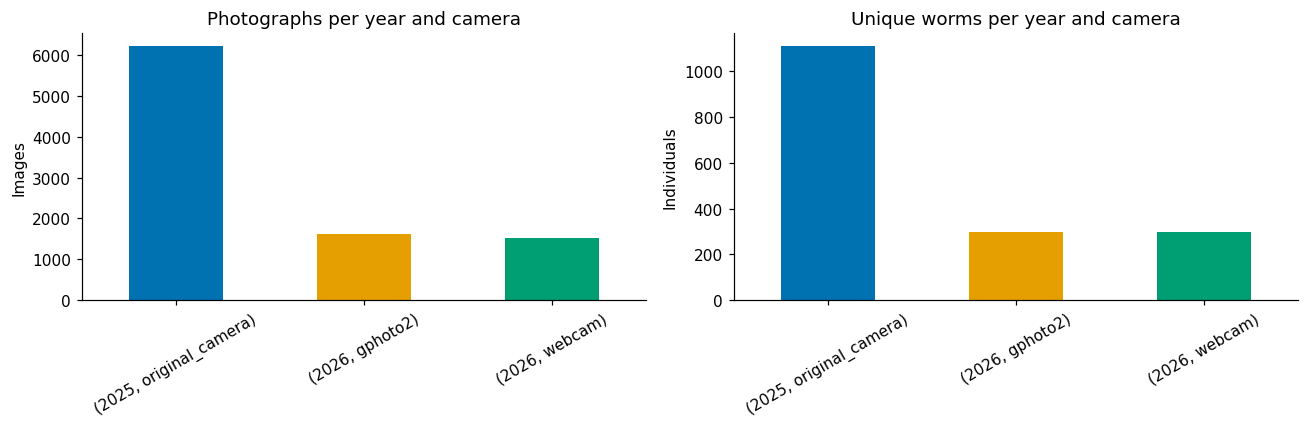

,count,mean,std,min,25%,50%,75%,max
cohort,,,,,,,,
2025 / original_camera,1109.0,5.60,1.00,2.0,5.0,5.0,6.0,14.0
2026 / gphoto2,296.0,5.48,1.11,5.0,5.0,5.0,5.0,11.0
2026 / webcam,296.0,5.13,0.47,4.0,5.0,5.0,5.0,8.0


In [30]:
composition = worms.groupby(["year", "camera"]).agg(
    images=("image_id", "size"), individuals=("individual_id", "nunique"),
    recorded_taxa=("taxon", "nunique"), segmented_images=("segmentation_ok", "sum")
)
composition["images_per_individual"] = (composition["images"] / composition["individuals"]).round(2)
by_year = worms.groupby("year").agg(images=("image_id", "size"), individuals=("individual_id", "nunique"))
display(composition)
display(by_year)
display(images.groupby(["year", "camera", "kind"]).size().rename("images").to_frame())
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
composition["images"].plot.bar(ax=axes[0], color=PALETTE, title="Photographs per year and camera")
composition["individuals"].plot.bar(ax=axes[1], color=PALETTE, title="Unique worms per year and camera")
for ax in axes:
    ax.set_xlabel(""); ax.tick_params(axis="x", labelrotation=30)
axes[0].set_ylabel("Images"); axes[1].set_ylabel("Individuals")
plt.tight_layout(); plt.show()
display(worms.groupby(["cohort", "individual_id"]).size().groupby("cohort").describe().round(2))


## 4. Recorded taxa and developmental stages

The first table counts images; the second counts unique individuals across
cameras. Ambiguous names such as `Lumbricus_sp` and taxonomic complexes are
retained as recorded. Differences here can change how difficult the external
test set is; these are composition differences, not model performance.


cohort,2025 / original_camera,2026 / gphoto2,2026 / webcam
taxon,,,
Allolobophora_chlorotica,992,227,220
Aporrectodea_caliginosa,205,109,110
Aporrectodea_caliginosa_tuberculata,2121,222,219
Aporrectodea_longa,888,456,419
Aporrectodea_rosea,287,272,261
Aporrectodea_tuberculata,627,167,145
Dendrobena_octaedra,7,0,0
Dendrodrilus_rubidus,9,0,0
Lumbricus_castaneus,22,0,0


year,2025,2026
taxon,,
Allolobophora_chlorotica,176,43
Aporrectodea_caliginosa,36,21
Aporrectodea_caliginosa_tuberculata,389,43
Aporrectodea_longa,159,81
Aporrectodea_rosea,53,52
Aporrectodea_tuberculata,105,28
Dendrobena_octaedra,1,0
Dendrodrilus_rubidus,1,0
Lumbricus_castaneus,4,0


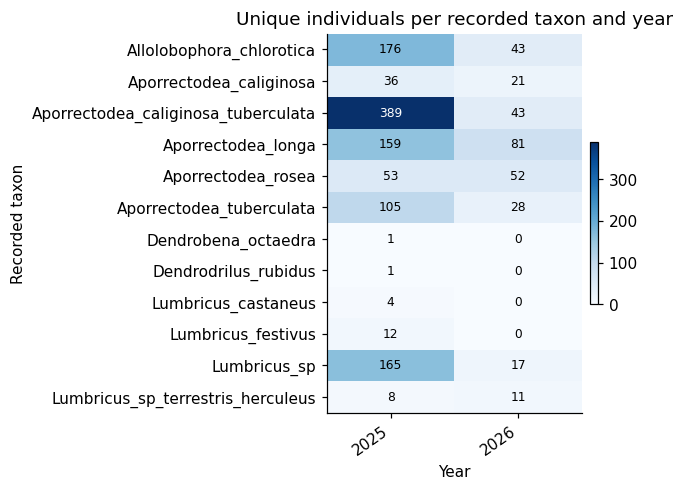

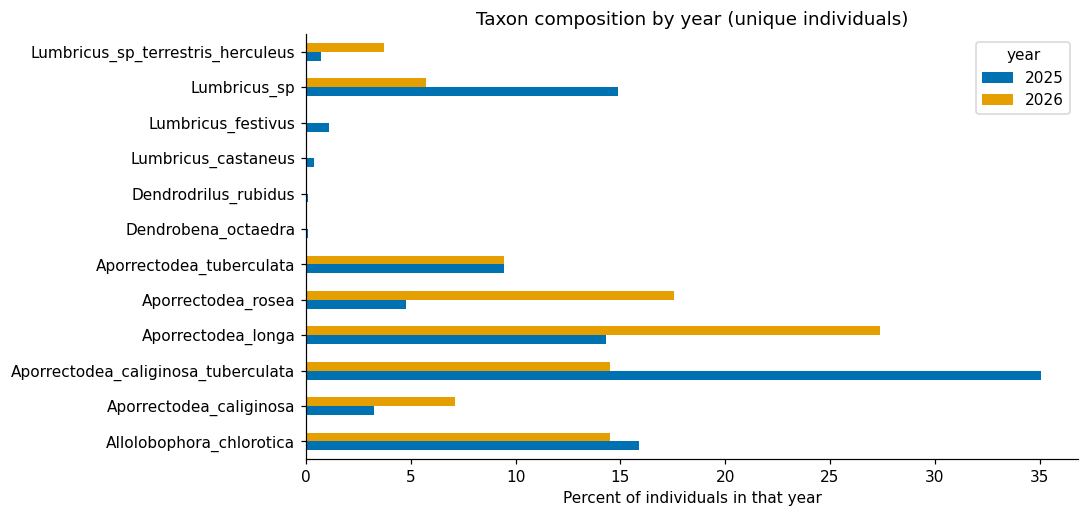

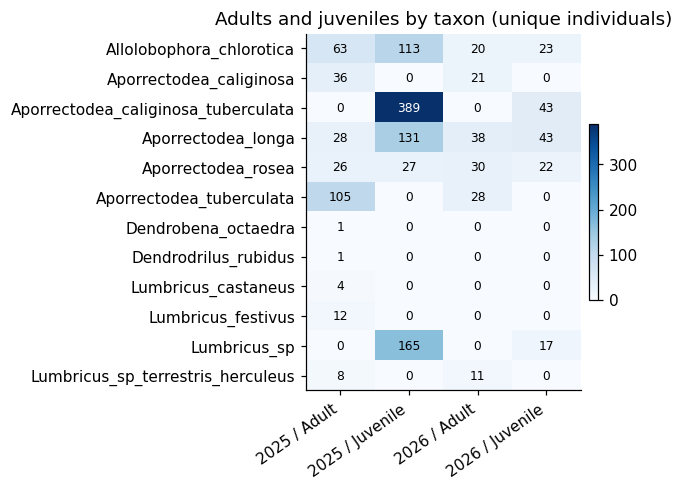

Only in latest year: []
Historical taxa absent from latest year: ['Dendrobena_octaedra', 'Dendrodrilus_rubidus', 'Lumbricus_castaneus', 'Lumbricus_festivus']
Recorded labels needing taxonomic interpretation: ['Aporrectodea_caliginosa_tuberculata', 'Lumbricus_sp', 'Lumbricus_sp_terrestris_herculeus']


In [31]:
taxon_images = pd.crosstab(worms["taxon"], worms["cohort"])
taxon_individuals = pd.crosstab(individuals["taxon"], individuals["year"])
display(taxon_images)
display(taxon_individuals)
heatmap(taxon_individuals, "Unique individuals per recorded taxon and year", "Year", "Recorded taxon")
proportions = taxon_individuals.div(taxon_individuals.sum(axis=0), axis=1).mul(100)
proportions.plot.barh(figsize=(10, max(4, len(proportions)*.4)), color=PALETTE,
                     title="Taxon composition by year (unique individuals)")
plt.xlabel("Percent of individuals in that year"); plt.ylabel("")
plt.tight_layout(); plt.show()
stage_counts = pd.crosstab(individuals["taxon"], [individuals["year"], individuals["life_stage"]])
stage_counts.columns = [f"{year} / {stage}" for year, stage in stage_counts.columns]
heatmap(stage_counts, "Adults and juveniles by taxon (unique individuals)")
years = sorted(worms["year"].unique())
if len(years) > 1:
    historical_taxa = set(worms.loc[worms["year"].ne(years[-1]), "taxon"])
    latest_taxa = set(worms.loc[worms["year"].eq(years[-1]), "taxon"])
    print("Only in latest year:", sorted(latest_taxa - historical_taxa))
    print("Historical taxa absent from latest year:", sorted(historical_taxa - latest_taxa))
uncertain_labels = sorted(t for t in worms["taxon"].unique() if len(t.split("_")) != 2 or "sp" in t.split("_"))
print("Recorded labels needing taxonomic interpretation:", uncertain_labels)


## 5. Locations and possible sampling imbalance

Codes remain strings. Historical locations were not recorded in this combined
manifest; they are shown as missing, never inferred. A specimen recorded at
multiple locations contributes to each corresponding location count, so these
totals may not be additive. No geographic coordinates are inferred from codes.


images  individuals
year location_display                     
2025 Not recorded        6215         1109
2026 04                   366           35
     05                   122           12
     09                   203           19
     143                  369           36
     147                   71            7
     535                  131           12
     ASKOV                494           48
     TAASTRUP             554           53
     TJELE                831           74

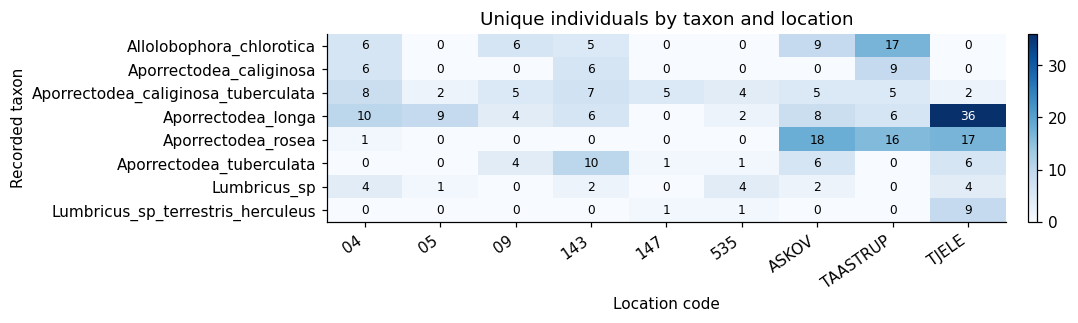

images  individuals
location_code camera                      
04            gphoto2     183           35
              webcam      183           35
05            gphoto2      61           12
              webcam       61           12
09            gphoto2     105           19
              webcam       98           19
143           gphoto2     186           36
              webcam      183           36
147           gphoto2      35            7
              webcam       36            7
535           gphoto2      67           12
              webcam       64           12
ASKOV         gphoto2     247           48
              webcam      247           48
TAASTRUP      gphoto2     283           53
              webcam      271           53
TJELE         gphoto2     455           74
              webcam      376           74

Individuals recorded at multiple locations: 0


In [32]:
location_counts = worms.groupby(["year", "location_display"]).agg(
    images=("image_id", "size"), individuals=("individual_id", "nunique"))
display(location_counts)
known_locations = worms.loc[worms["location_code"].ne("")]
if not known_locations.empty:
    location_taxa = known_locations.groupby(["taxon", "location_code"])["individual_id"].nunique().unstack(fill_value=0)
    heatmap(location_taxa, "Unique individuals by taxon and location", "Location code", "Recorded taxon")
    display(known_locations.groupby(["location_code", "camera"]).agg(
        images=("image_id", "size"), individuals=("individual_id", "nunique")))
multiple_locations = worms.loc[worms["location_code"].ne("")].groupby("individual_id")["location_code"].nunique()
print("Individuals recorded at multiple locations:", int(multiple_locations.gt(1).sum()))


## 6. Camera coverage and repeated photographs

Pair cameras by biological individual. Image numbers can differ between
cameras; matching image numbers is not assumed to mean matching photographs.
Session-level coverage below only establishes a shared capture session.


,individuals
Both cameras,296
gphoto2 only,0
webcam only,0


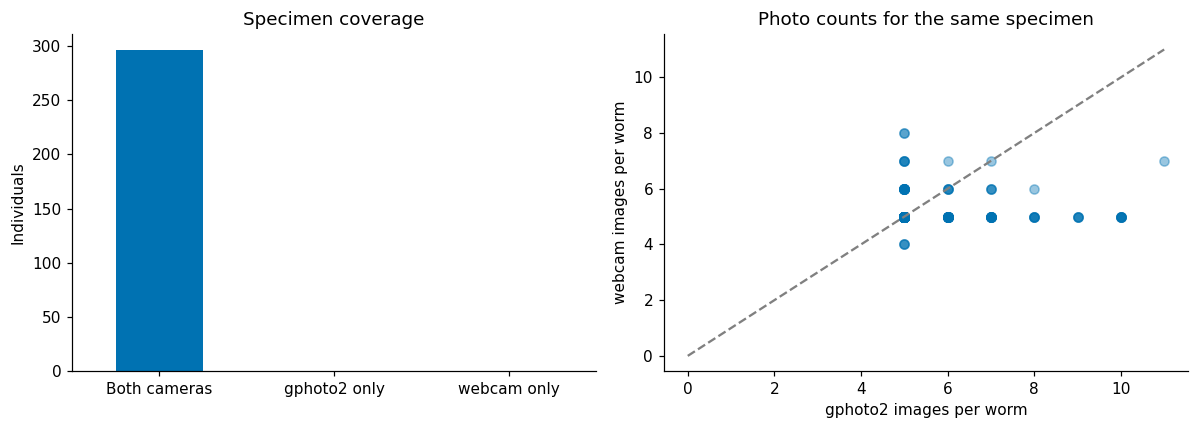

Capture sessions containing both cameras: 296 / 296


camera,gphoto2,webcam
individual_id,,


In [33]:
new_worms = worms.loc[worms["camera"].isin(["gphoto2", "webcam"])].copy()
camera_counts = new_worms.groupby(["individual_id", "camera"]).size().unstack(fill_value=0)
camera_counts = camera_counts.reindex(columns=["gphoto2", "webcam"], fill_value=0)
if not camera_counts.empty:
    both = camera_counts.gt(0).all(axis=1)
    coverage = pd.Series({
        "Both cameras": int(both.sum()),
        "gphoto2 only": int((camera_counts.gphoto2.gt(0) & camera_counts.webcam.eq(0)).sum()),
        "webcam only": int((camera_counts.webcam.gt(0) & camera_counts.gphoto2.eq(0)).sum()),
    }, name="individuals")
    display(coverage.to_frame())
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    coverage.plot.bar(ax=axes[0], color=PALETTE[:3], rot=0, title="Specimen coverage")
    axes[0].set_ylabel("Individuals")
    axes[1].scatter(camera_counts.gphoto2, camera_counts.webcam, alpha=.4, color=PALETTE[0])
    high = max(camera_counts.max().max(), 1)
    axes[1].plot([0, high], [0, high], "--", color="gray")
    axes[1].set(xlabel="gphoto2 images per worm", ylabel="webcam images per worm", title="Photo counts for the same specimen")
    plt.tight_layout(); plt.show()
    sessions = new_worms.groupby(["individual_id", "capture_id"])["camera"].nunique()
    print("Capture sessions containing both cameras:", int(sessions.eq(2).sum()), "/", len(sessions))
    display(camera_counts.loc[~both].head(20))
else:
    print("No new camera rows yet.")


## 7. Segmentation progress, failures and coverage

**Reused** means an existing historical segmentation was copied. **Segmented**
means the new workflow produced an output. **Pending** is not a failure.
Attempt success is `segmented / (segmented + failed)` and excludes reused
outputs and pending images. It is an operational success rate, **not an accuracy
score for the mask**. Compare camera rates only after both have been processed.


segmentation_status,reused,segmented,failed,pending,not_yet_published,total_images,attempted_new,attempt_success_pct,available_pct
cohort,,,,,,,,,
2025 / original_camera,6207,6,2,0,0,6215,8,75.0,100.0
2026 / gphoto2,0,1622,0,0,0,1622,1622,100.0,100.0
2026 / webcam,0,1460,59,0,0,1519,1519,96.1,96.1


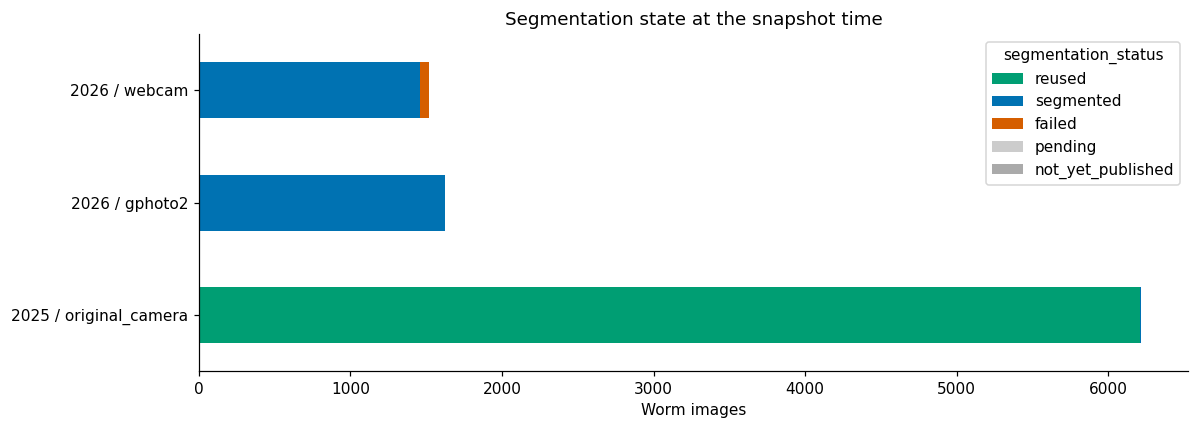

,all_individuals,individuals_with_output,individuals_without_output
cohort,,,
2025 / original_camera,1109,1108,1
2026 / gphoto2,296,296,0
2026 / webcam,296,293,3


attempted  \
cohort                 taxon                               life_stage              
2026 / webcam          Aporrectodea_longa                  Juvenile          223   
                       Aporrectodea_caliginosa_tuberculata Juvenile          219   
                       Aporrectodea_rosea                  Juvenile          110   
                       Allolobophora_chlorotica            Juvenile          117   
                       Aporrectodea_tuberculata            Adult             145   
                       Allolobophora_chlorotica            Adult             103   
                       Lumbricus_sp                        Juvenile           86   
2025 / original_camera Aporrectodea_rosea                  Juvenile            2   
2026 / gphoto2         Aporrectodea_longa                  Adult             236   
                       Aporrectodea_caliginosa_tuberculata Juvenile          222   
                       Aporrectodea_longa                  Juvenile          220   
2026 / webcam          Aporrectodea_longa                  Adult             196   
2026 / gphoto2         Aporrectodea_tuberculata            Adult             167   
                       Aporrectodea_rosea                  Adult             156   
2026 / webcam          Aporrectodea_rosea                  Adult             151   
2026 / gphoto2         Allolobophora_chlorotica            Juvenile          122   
                       Aporrectodea_rosea                  Juvenile          116   
2026 / webcam          Aporrectodea_caliginosa             Adult             110   
2026 / gphoto2         Aporrectodea_caliginosa             Adult             109   
                       Allolobophora_chlorotica            Adult             105   
                       Lumbricus_sp                        Juvenile           94   
                       Lumbricus_sp_terrestris_herculeus   Adult              75   
2026 / webcam          Lumbricus_sp_terrestris_herculeus   Adult              59   
2025 / original_camera Aporrectodea_caliginosa_tuberculata Juvenile            6   

                                                                       failed  \
cohort                 taxon                               life_stage           
2026 / webcam          Aporrectodea_longa                  Juvenile        25   
                       Aporrectodea_caliginosa_tuberculata Juvenile        12   
                       Aporrectodea_rosea                  Juvenile         9   
                       Allolobophora_chlorotica            Juvenile         7   
                       Aporrectodea_tuberculata            Adult            2   
                       Allolobophora_chlorotica            Adult            2   
                       Lumbricus_sp                        Juvenile         2   
2025 / original_camera Aporrectodea_rosea                  Juvenile         2   
2026 / gphoto2         Aporrectodea_longa                  Adult            0   
                       Aporrectodea_caliginosa_tuberculata Juvenile         0   
                       Aporrectodea_longa                  Juvenile         0   
2026 / webcam          Aporrectodea_longa                  Adult            0   
2026 / gphoto2         Aporrectodea_tuberculata            Adult            0   
                       Aporrectodea_rosea                  Adult            0   
2026 / webcam          Aporrectodea_rosea                  Adult            0   
2026 / gphoto2         Allolobophora_chlorotica            Juvenile         0   
                       Aporrectodea_rosea                  Juvenile         0   
2026 / webcam          Aporrectodea_caliginosa             Adult            0   
2026 / gphoto2         Aporrectodea_caliginosa             Adult            0   
                       Allolobophora_chlorotica            Adult            0   
                       Lumbricus_sp                        Juvenile         0   
                       

,image_id,cohort,barcode,location_code,raw_path,segmentation_error
4361,d27176deddf1aea93d919207,2025 / original_camera,Aporrectodea_rosea_Juvenile_04,,2025/original_camera/00_RawData/Aporrectodea_r...,No usable mask; inspect this image before retr...
4362,21af0cf91fd38d5b0cb6b676,2025 / original_camera,Aporrectodea_rosea_Juvenile_04,,2025/original_camera/00_RawData/Aporrectodea_r...,No usable mask; inspect this image before retr...
6374,00cc19376369524d52442a71,2026 / webcam,Aporrectodea_rosea_Juvenile_36,ASKOV,2026/webcam/00_RawData/Aporrectodea_rosea_Juve...,No usable mask; inspect this image before retr...
6375,db3750713dd99c636206d99f,2026 / webcam,Aporrectodea_rosea_Juvenile_36,ASKOV,2026/webcam/00_RawData/Aporrectodea_rosea_Juve...,No usable mask; inspect this image before retr...
6376,304f90c8e2dfe6f724c84e60,2026 / webcam,Aporrectodea_rosea_Juvenile_36,ASKOV,2026/webcam/00_RawData/Aporrectodea_rosea_Juve...,No usable mask; inspect this image before retr...
6377,3adf12d4a8c57a463f2089c6,2026 / webcam,Aporrectodea_rosea_Juvenile_36,ASKOV,2026/webcam/00_RawData/Aporrectodea_rosea_Juve...,No usable mask; inspect this image before retr...
6378,c08cc404f64c0282d83a3a00,2026 / webcam,Aporrectodea_rosea_Juvenile_36,ASKOV,2026/webcam/00_RawData/Aporrectodea_rosea_Juve...,No usable mask; inspect this image before retr...
6457,d65e59f2060b3c091965d4c5,2026 / webcam,Aporrectodea_longa_Juvenile_147,04,2026/webcam/00_RawData/Aporrectodea_longa_Juve...,No usable mask; inspect this image before retr...
6483,ca134b6932417c7ede6cd596,2026 / webcam,Aporrectodea_longa_Juvenile_144,04,2026/webcam/00_RawData/Aporrectodea_longa_Juve...,No usable mask; inspect this image before retr...
6515,57b38c99aa79b979fd3ce7db,2026 / webcam,Aporrectodea_caliginosa_tuberculata_Juvenile_397,04,2026/webcam/00_RawData/Aporrectodea_caliginosa...,No usable mask; inspect this image before retr...


In [34]:
status_order = ["reused", "segmented", "failed", "pending", "not_yet_published"]
status = pd.crosstab(worms["cohort"], worms["segmentation_status"]).reindex(columns=status_order, fill_value=0)
progress = status.copy()
progress["total_images"] = status.sum(axis=1)
progress["attempted_new"] = status.segmented + status.failed
progress["attempt_success_pct"] = status.segmented.div(progress.attempted_new.replace(0, np.nan)).mul(100).round(1)
progress["available_pct"] = (status.segmented + status.reused).div(progress.total_images).mul(100).round(1)
display(progress)
status.plot.barh(stacked=True, figsize=(11, 4), color=[PALETTE[2], PALETTE[0], PALETTE[5], "#CCCCCC", "#AAAAAA"])
plt.xlabel("Worm images"); plt.ylabel(""); plt.title("Segmentation state at the snapshot time")
plt.tight_layout(); plt.show()
successful = worms.loc[worms["segmentation_ok"]]
availability = worms.groupby("cohort")["individual_id"].nunique().rename("all_individuals").to_frame()
availability["individuals_with_output"] = successful.groupby("cohort")["individual_id"].nunique().reindex(availability.index, fill_value=0)
availability["individuals_without_output"] = availability.all_individuals - availability.individuals_with_output
display(availability)
attempts = worms.loc[worms["segmentation_status"].isin(["segmented", "failed"])].copy()
if not attempts.empty:
    attempts["failed"] = attempts["segmentation_status"].eq("failed")
    failure_rates = attempts.groupby(["cohort", "taxon", "life_stage"]).agg(
        attempted=("image_id", "size"), failed=("failed", "sum"))
    failure_rates["failure_pct"] = (100 * failure_rates.failed / failure_rates.attempted).round(1)
    display(failure_rates.sort_values(["failed", "attempted"], ascending=False).head(25))
failed = worms.loc[worms["segmentation_status"].eq("failed")]
display(failed[["image_id", "cohort", "barcode", "location_code", "raw_path", "segmentation_error"]].head(25))


## 8. Collection dates and specimen weights

Dates are parsed in UTC. Daily specimen counts are unique within each day;
the same worm can appear on several days. Weight plots use **one median weight
per biological individual**, combining repeated camera records. Nonpositive
or missing weights are excluded and counted explicitly.


,,images,individuals
date,cohort,,
2025-09-02,2025 / original_camera,225,43
2025-09-04,2025 / original_camera,774,136
2025-09-05,2025 / original_camera,603,111
2025-09-10,2025 / original_camera,810,150
2025-09-17,2025 / original_camera,820,148
2025-09-18,2025 / original_camera,1436,261
2025-10-10,2025 / original_camera,526,90
2025-11-04,2025 / original_camera,1021,170
2026-09-03,2026 / gphoto2,884,169


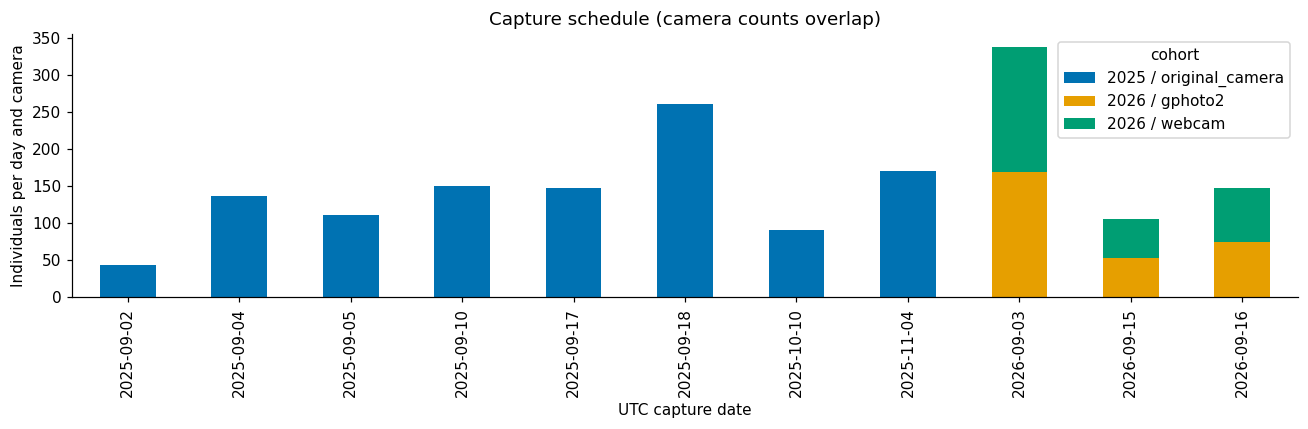

Images with unparseable timestamps: 0
Image rows with missing/nonpositive weights: 0


count   mean    std    min    25%    50%    75%    max
year life_stage                                                        
2025 Adult       284.0  0.765  0.551  0.080  0.355  0.671  1.033  4.236
     Juvenile    825.0  0.332  0.284  0.007  0.145  0.251  0.430  2.330
2026 Adult       148.0  0.781  0.639  0.065  0.284  0.556  1.136  2.995
     Juvenile    148.0  0.377  0.411  0.005  0.112  0.232  0.516  2.364

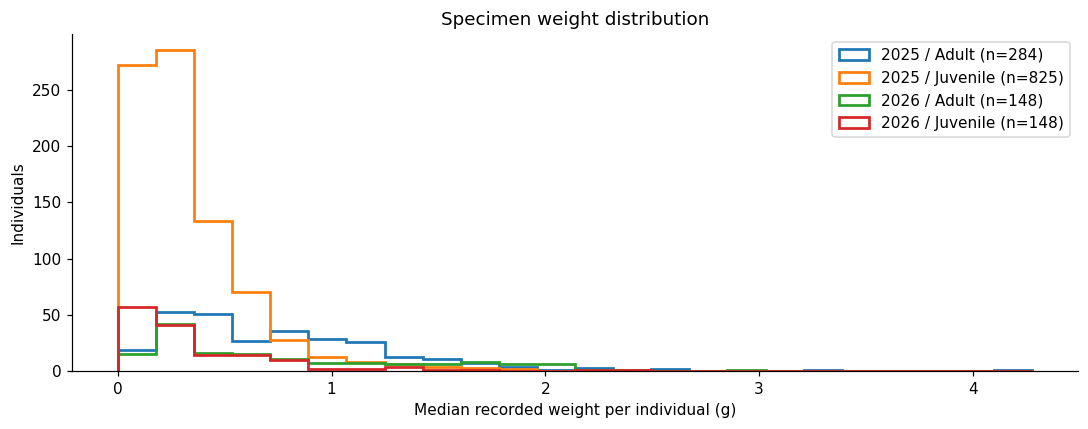

In [35]:
dated = worms.loc[worms["captured_at"].notna()].copy()
dated["date"] = dated["captured_at"].dt.date
daily = dated.groupby(["date", "cohort"]).agg(images=("image_id", "size"), individuals=("individual_id", "nunique"))
display(daily.tail(20))
if not daily.empty:
    daily["individuals"].unstack(fill_value=0).plot.bar(stacked=True, figsize=(12, 4), color=PALETTE)
    plt.ylabel("Individuals per day and camera"); plt.xlabel("UTC capture date")
    plt.title("Capture schedule (camera counts overlap)"); plt.tight_layout(); plt.show()
print("Images with unparseable timestamps:", int(worms.captured_at.isna().sum()))
print("Image rows with missing/nonpositive weights:", int((worms.weight_numeric.isna() | worms.weight_numeric.le(0)).sum()))
weight_rows = worms.loc[worms.weight_numeric.gt(0)]
weights = weight_rows.groupby("individual_id")["weight_numeric"].median().rename("weight_g").to_frame()
weights = weights.join(individuals.set_index("individual_id")[["year", "taxon", "life_stage"]])
if not weights.empty:
    display(weights.groupby(["year", "life_stage"]).weight_g.describe().round(3))
    fig, ax = plt.subplots(figsize=(10, 4))
    for (year, stage), group in weights.groupby(["year", "life_stage"]):
        ax.hist(group.weight_g, bins=np.linspace(0, weights.weight_g.max()*1.01, 25),
                histtype="step", linewidth=1.8, label=f"{year} / {stage} (n={len(group)})")
    ax.set(xlabel="Median recorded weight per individual (g)", ylabel="Individuals", title="Specimen weight distribution")
    ax.legend(); plt.tight_layout(); plt.show()


## 9. Identity, label and original split checks

These checks inspect metadata, not a new train/test split. Historical images
without paper membership remain unassigned. A repeated barcode across years
requires identity review; a new year prefix alone cannot prove independence.
Camera copies of one specimen must stay together in any future training split.


In [36]:
label_conflicts = worms.groupby("individual_id")[["taxon", "life_stage"]].nunique()
label_conflicts = label_conflicts.loc[label_conflicts.gt(1).any(axis=1)]
duplicate_ids = images.loc[images.image_id.duplicated(keep=False)]
duplicate_paths = images.loc[images.raw_path.duplicated(keep=False)]
cross_year_barcodes = worms.groupby("barcode").year.nunique()
cross_year_barcodes = cross_year_barcodes.loc[cross_year_barcodes.gt(1)]
split_rows = worms.loc[worms.original_paper_split.ne("")]
split_membership = split_rows.groupby("individual_id").original_paper_split.nunique()
split_conflicts = split_membership.loc[split_membership.gt(1)]
checks = pd.Series({
    "duplicate_image_id_rows": len(duplicate_ids),
    "duplicate_raw_path_rows": len(duplicate_paths),
    "individuals_with_conflicting_taxon_or_stage": len(label_conflicts),
    "barcodes_present_in_multiple_years": len(cross_year_barcodes),
    "individuals_in_multiple_original_paper_splits": len(split_conflicts),
    "worms_with_missing_taxon": int(worms.taxon.eq("").sum()),
    "worms_with_missing_life_stage": int(worms.life_stage.eq("").sum()),
}, name="count")
display(checks.to_frame())
display(worms.groupby("dataset_role").agg(images=("image_id", "size"), individuals=("individual_id", "nunique")))
display(split_rows.groupby("original_paper_split").agg(images=("image_id", "size"), individuals=("individual_id", "nunique")))
if not label_conflicts.empty: display(label_conflicts)
if not split_conflicts.empty: display(split_conflicts)
if not cross_year_barcodes.empty: display(cross_year_barcodes.to_frame("years"))
if not duplicate_ids.empty: display(duplicate_ids[["image_id", "raw_path"]])


,count
duplicate_image_id_rows,0
duplicate_raw_path_rows,0
individuals_with_conflicting_taxon_or_stage,0
barcodes_present_in_multiple_years,0
individuals_in_multiple_original_paper_splits,0
worms_with_missing_taxon,0
worms_with_missing_life_stage,0


,images,individuals
dataset_role,,
external_test,1622,296
historical_unassigned,24,4
paper_test,1274,221
paper_train,3996,718
paper_val,921,166
reserved,1519,296


,images,individuals
original_paper_split,,
test,1274,221
train,3996,718
val,921,166


## 10. Sampled image dimensions, brightness and mask coverage

This section samples up to `IMAGE_SAMPLE_PER_CAMERA` images per year/camera.
It reports dimensions, file size and mean grayscale intensity. These are
descriptive checks; lighting, framing and specimen content differ, so they
do not establish which camera is scientifically better. Mask coverage is
measured on a reduced mask preview. Historical masks are compared with the
raw image, **never with the differently sized segmented crop**.


## 11. Inspect original images, masks and segmented crops

Each preview uses a mask in **raw-image coordinates**. The black-background
crop is displayed separately. If an old mask's dimensions/orientation do not
match the raw image, the overlay is skipped rather than resized into alignment.
These examples help inspect masks; successful file creation alone does not
demonstrate correct biological segmentation.


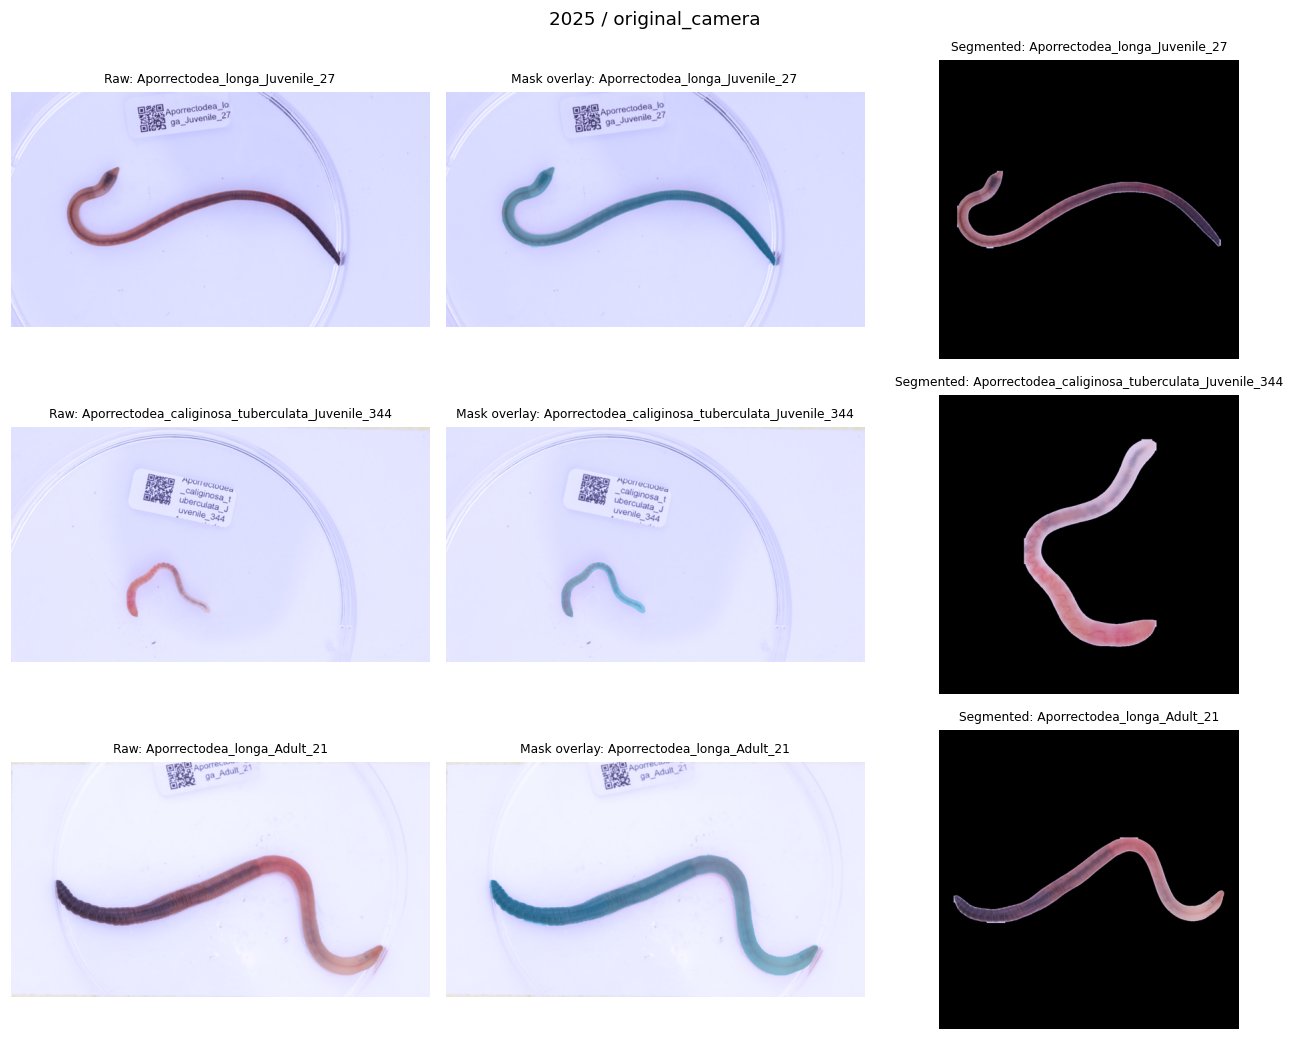

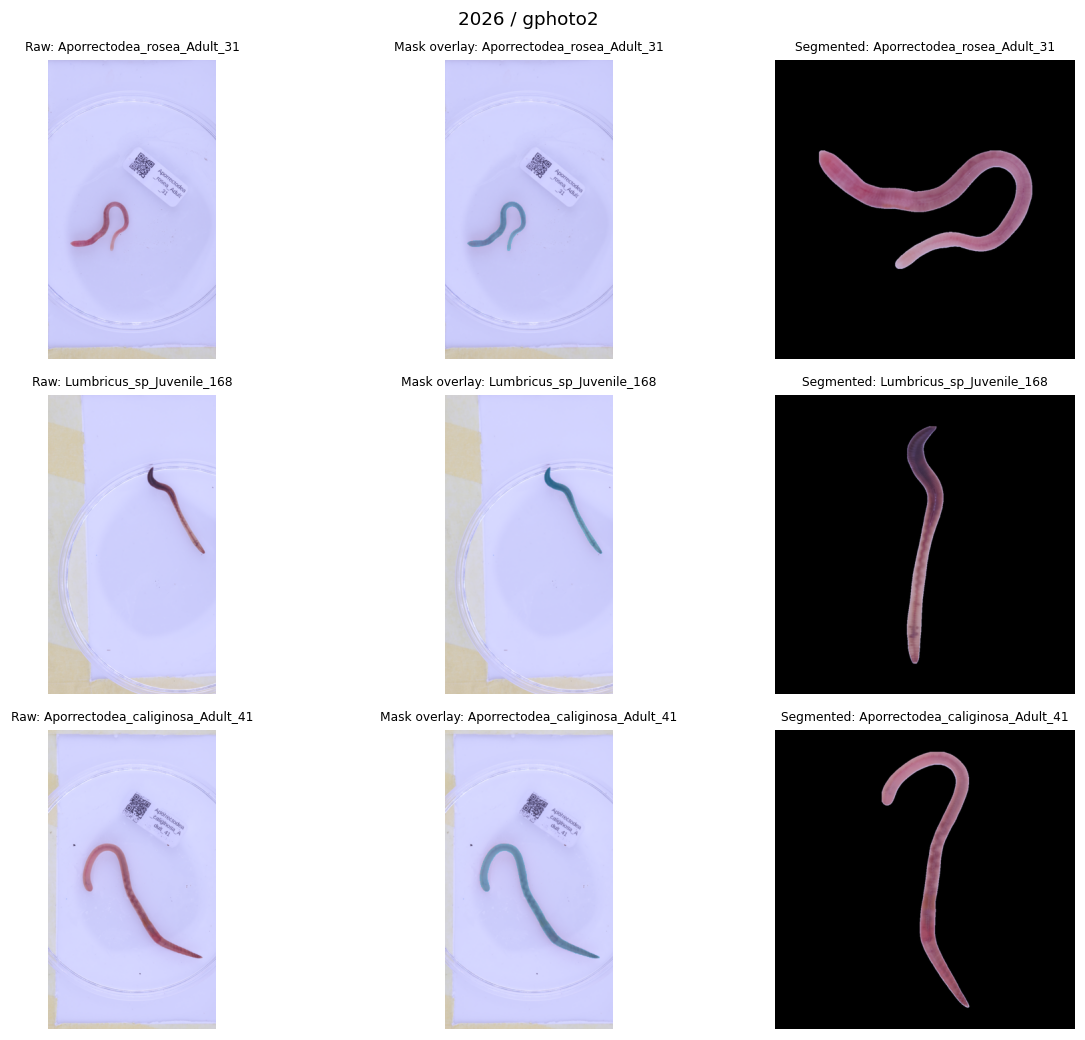

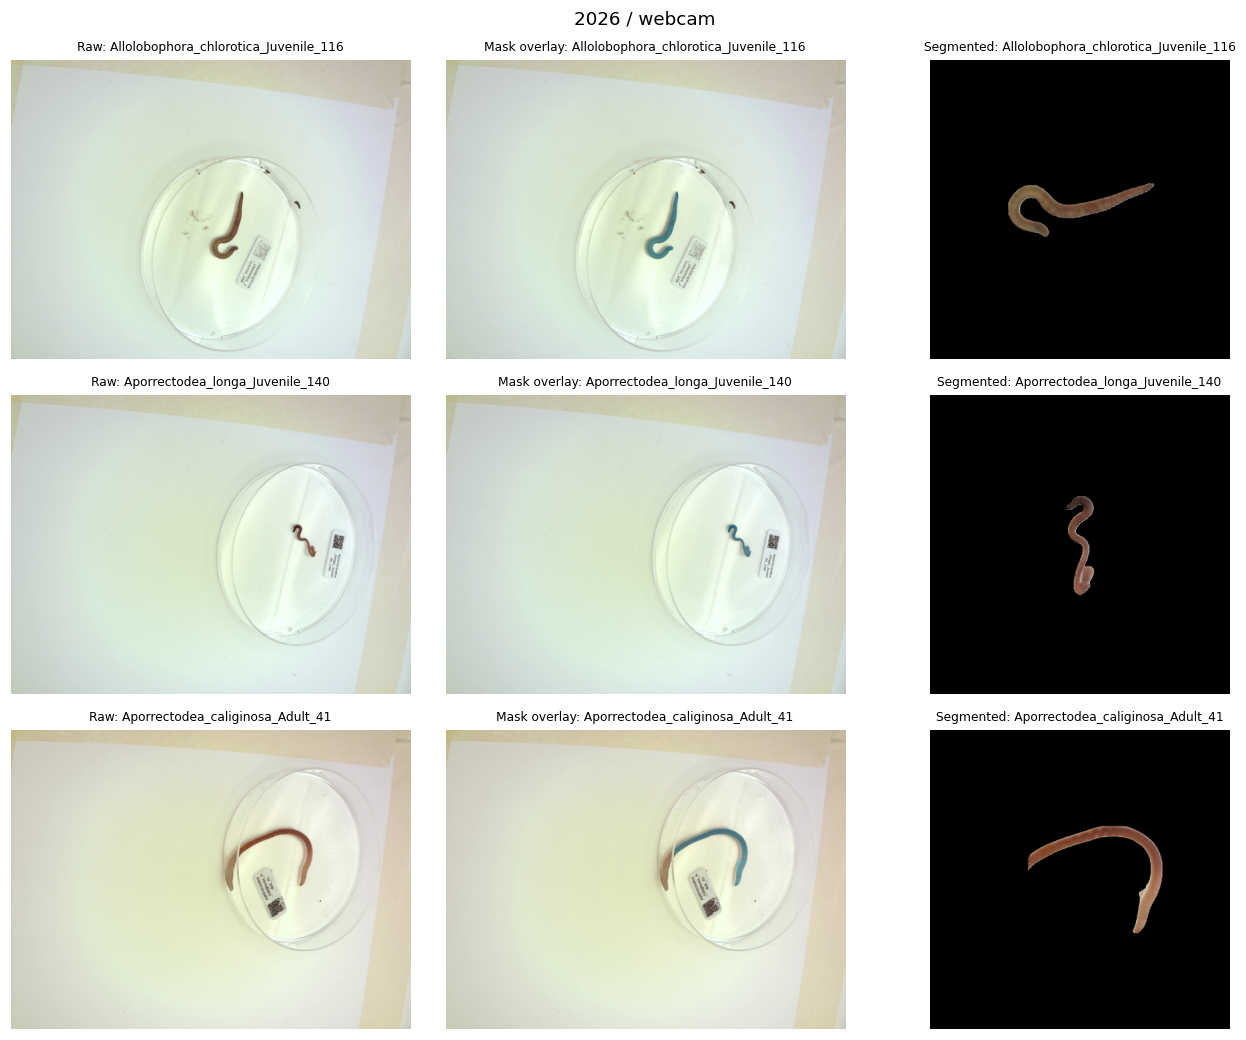

In [37]:
def raw_overlay(row):
    with Image.open(dataset_path(row["raw_path"])) as source:
        # Historical segmentation used the stored pixel orientation.
        raw = source.copy() if row["segmentation_status"] == "reused" else ImageOps.exif_transpose(source)
        raw = raw.convert("RGB")
    with Image.open(dataset_path(row["raw_mask_path"])) as source:
        mask = source.convert("L")
    if raw.size != mask.size:
        raise ValueError(f"Raw/mask dimensions differ: {raw.size} vs {mask.size}")
    raw.thumbnail((600, 450))
    mask = mask.resize(raw.size, Image.Resampling.NEAREST)
    pixels = np.asarray(raw).copy()
    foreground = np.asarray(mask)>0
    pixels[foreground] = (.65*pixels[foreground] + .35*np.array([0, 200, 255])).astype(np.uint8)
    return pixels

def show_segmentation_examples(frame, n=3):
    selected = sample_by_camera(frame, n)
    if selected.empty:
        print("No successful segmentation examples in this snapshot."); return
    for cohort, group in selected.groupby("cohort"):
        fig, axes = plt.subplots(len(group), 3, figsize=(12, 3.2*len(group)), squeeze=False)
        fig.suptitle(cohort)
        for axes_row, row in zip(axes, group.to_dict("records")):
            previews = [("Raw", lambda: thumbnail(row["raw_path"])),
                        ("Mask overlay", lambda: raw_overlay(row)),
                        ("Segmented", lambda: thumbnail(row["segmented_path"], orient=False))]
            for ax, (title, get_image) in zip(axes_row, previews):
                try: ax.imshow(get_image())
                except (OSError, ValueError) as error: ax.text(.03, .5, str(error), wrap=True, fontsize=8)
                ax.set_title(f"{title}: {row['barcode']}", fontsize=8); ax.axis("off")
        plt.tight_layout(); plt.show()
if SHOW_GALLERIES:
    show_segmentation_examples(worms.loc[worms.segmentation_ok], GALLERY_EXAMPLES)


## 12. Compare the cameras on the same specimen; inspect failures

These are representative photos of the same specimen in a shared capture
session, **not necessarily simultaneous exposures**. They help separate
camera appearance from differences in which worms were sampled. Failed-image
previews are for manual review; this notebook does not modify their status.


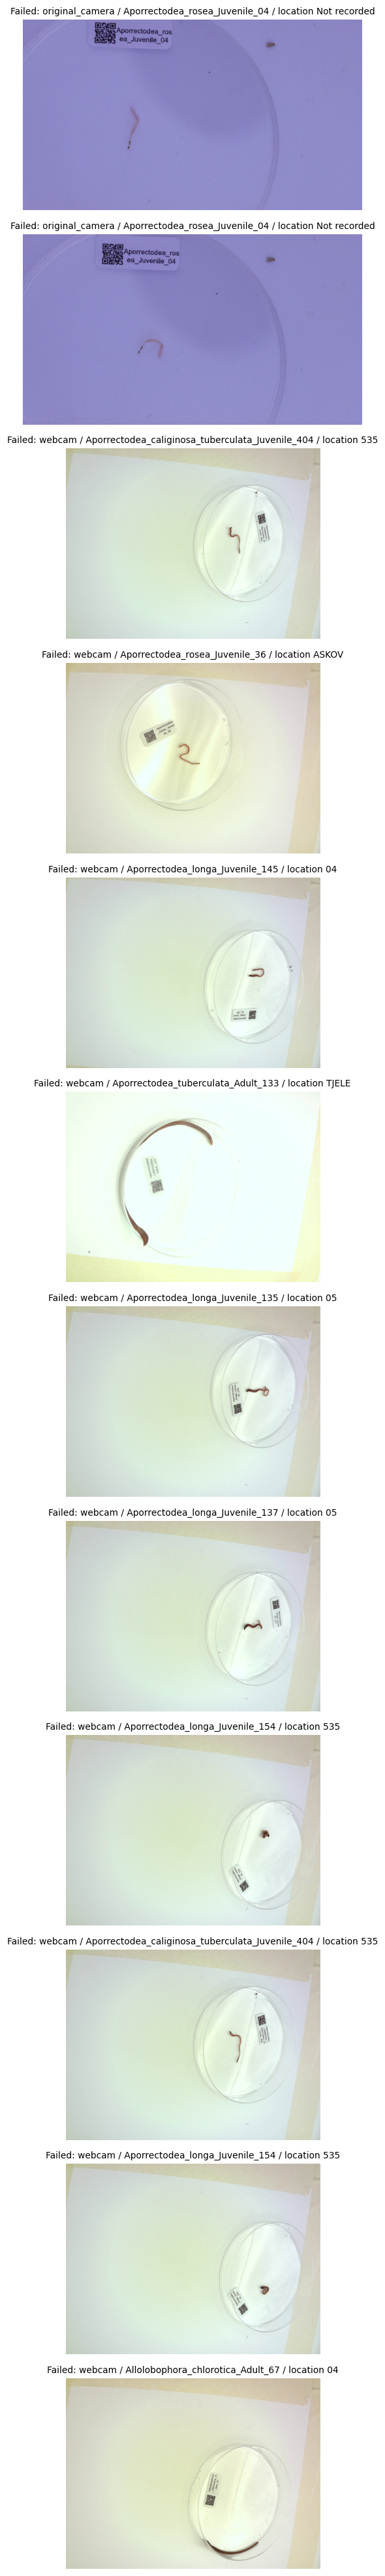

In [39]:
if SHOW_GALLERIES and not new_worms.empty:
    shared_sessions = new_worms.groupby(["individual_id", "capture_id"])["camera"].nunique()
    keys = sorted(shared_sessions.loc[shared_sessions.eq(2)].index)
    rng = np.random.default_rng(RANDOM_SEED)
    chosen = [keys[i] for i in rng.choice(len(keys), min(GALLERY_EXAMPLES, len(keys)), replace=False)] if keys else []
    failed_examples = sample_by_camera(failed, 10)
    if not failed_examples.empty:
        fig, axes = plt.subplots(len(failed_examples), 1, figsize=(9, 3*len(failed_examples)), squeeze=False)
        for ax, row in zip(axes.flat, failed_examples.to_dict("records")):
            try: ax.imshow(thumbnail(row["raw_path"]))
            except (OSError, ValueError) as error: ax.text(.03, .5, str(error), wrap=True)
            ax.set_title(f"Failed: {row['camera']} / {row['barcode']} / location {row['location_display']}", fontsize=9)
            ax.axis("off")
        plt.tight_layout(); plt.show()


## Refreshing and interpreting the notebook

Use **Run All** to reload the latest published metadata and refresh every view.
Values above describe the snapshot timestamp shown in section 2. A pending
count does not establish that the process is still running, and a low failure
count during an incomplete run does not establish the final failure rate.

Useful follow-up questions: Are taxa or life stages concentrated at particular
locations? Are some worms missing a camera? Are segmentation failures concentrated
in one taxon or camera? Do any specimens have no usable segmented image? Are
new taxa absent from the historical dataset? These checks should inform later
classifier evaluation while keeping the new gphoto2 cohort as external test.
